In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import SGD

import numpy as np

In [2]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_layer = nn.Linear(in_features=4, out_features=8)
        self.hidden_layer = nn.Linear(in_features=8, out_features=8)
        self.output_layer = nn.Linear(in_features=8, out_features=2)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        x = F.relu(self.hidden_layer(x))

        return self.output_layer(x)

In [3]:
layer = nn.Linear(4, 8) # layer of 8 neurons, expecting 4 parameters as input and producing 8 as output
layer.state_dict()

OrderedDict([('weight',
              tensor([[ 0.1848, -0.1631,  0.4291,  0.4605],
                      [-0.0946, -0.1610,  0.4667,  0.0868],
                      [-0.4567,  0.4409,  0.1962, -0.4001],
                      [ 0.1143, -0.4542, -0.0706,  0.4423],
                      [-0.1771, -0.2485,  0.4630,  0.2011],
                      [ 0.3781,  0.3176,  0.2741, -0.1365],
                      [ 0.3190,  0.4657,  0.3211,  0.2641],
                      [ 0.3212, -0.1278,  0.0919, -0.0263]])),
             ('bias',
              tensor([ 0.0527, -0.4846,  0.0556,  0.4335, -0.0896,  0.1017,  0.2745,  0.1958]))])

In [4]:
tens = torch.randn(1, 4) # creating random tensor of 1 row (observation) with 4 parameteres each

In [5]:
tens

tensor([[ 1.6952, -0.5385,  0.3831,  0.2656]])

In [6]:
layer(tens) 

tensor([[ 0.7406, -0.3564, -0.9872,  0.9623, -0.0252,  0.6404,  0.7576,  0.8374]],
       grad_fn=<AddmmBackward0>)

In [7]:
simple_nn = SimpleNN()

In [8]:
simple_nn(tens)

tensor([[0.4501, 0.0978]], grad_fn=<AddmmBackward0>)

In [9]:
obs = 400
input_params = 4
output_params = 2
x_train = torch.randn(obs, input_params)
y_train = torch.randn(obs, output_params)

In [10]:
simple_nn.training

True

In [11]:
simple_nn.state_dict().keys()

odict_keys(['input_layer.weight', 'input_layer.bias', 'hidden_layer.weight', 'hidden_layer.bias', 'output_layer.weight', 'output_layer.bias'])

In [12]:
next(simple_nn.parameters())

Parameter containing:
tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
        [-0.2741,  0.2106, -0.4446, -0.2320],
        [ 0.3725,  0.1478,  0.4084, -0.4724],
        [ 0.4263,  0.2690, -0.1032,  0.2336],
        [-0.0904, -0.4333,  0.0173, -0.4289],
        [ 0.4772, -0.3044, -0.0155, -0.1224],
        [-0.0426, -0.1830, -0.0337, -0.0657],
        [-0.4237,  0.4478,  0.4145,  0.3324]], requires_grad=True)

In [13]:
next(simple_nn.output_layer.parameters())

Parameter containing:
tensor([[ 0.3178,  0.0593,  0.2566, -0.3285, -0.2216,  0.0742, -0.0649,  0.2237],
        [-0.3104,  0.3529, -0.0790,  0.0588,  0.0387, -0.0510, -0.2866,  0.2370]],
       requires_grad=True)

In [14]:
tens

tensor([[ 1.6952, -0.5385,  0.3831,  0.2656]])

In [15]:
next(simple_nn.parameters())

Parameter containing:
tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
        [-0.2741,  0.2106, -0.4446, -0.2320],
        [ 0.3725,  0.1478,  0.4084, -0.4724],
        [ 0.4263,  0.2690, -0.1032,  0.2336],
        [-0.0904, -0.4333,  0.0173, -0.4289],
        [ 0.4772, -0.3044, -0.0155, -0.1224],
        [-0.0426, -0.1830, -0.0337, -0.0657],
        [-0.4237,  0.4478,  0.4145,  0.3324]], requires_grad=True)

In [16]:
simple_nn.input_layer.state_dict()

OrderedDict([('weight',
              tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
                      [-0.2741,  0.2106, -0.4446, -0.2320],
                      [ 0.3725,  0.1478,  0.4084, -0.4724],
                      [ 0.4263,  0.2690, -0.1032,  0.2336],
                      [-0.0904, -0.4333,  0.0173, -0.4289],
                      [ 0.4772, -0.3044, -0.0155, -0.1224],
                      [-0.0426, -0.1830, -0.0337, -0.0657],
                      [-0.4237,  0.4478,  0.4145,  0.3324]])),
             ('bias',
              tensor([ 0.4548,  0.0797,  0.3759, -0.3988,  0.1598,  0.0627, -0.0897, -0.3564]))])

In [17]:
simple_nn.state_dict().keys()

odict_keys(['input_layer.weight', 'input_layer.bias', 'hidden_layer.weight', 'hidden_layer.bias', 'output_layer.weight', 'output_layer.bias'])

In [18]:
simple_nn.state_dict()['input_layer.weight']

tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
        [-0.2741,  0.2106, -0.4446, -0.2320],
        [ 0.3725,  0.1478,  0.4084, -0.4724],
        [ 0.4263,  0.2690, -0.1032,  0.2336],
        [-0.0904, -0.4333,  0.0173, -0.4289],
        [ 0.4772, -0.3044, -0.0155, -0.1224],
        [-0.0426, -0.1830, -0.0337, -0.0657],
        [-0.4237,  0.4478,  0.4145,  0.3324]])

In [19]:

simple_nn.input_layer.weight

Parameter containing:
tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
        [-0.2741,  0.2106, -0.4446, -0.2320],
        [ 0.3725,  0.1478,  0.4084, -0.4724],
        [ 0.4263,  0.2690, -0.1032,  0.2336],
        [-0.0904, -0.4333,  0.0173, -0.4289],
        [ 0.4772, -0.3044, -0.0155, -0.1224],
        [-0.0426, -0.1830, -0.0337, -0.0657],
        [-0.4237,  0.4478,  0.4145,  0.3324]], requires_grad=True)

In [20]:
y_pred = simple_nn(tens)

In [21]:
y_pred

tensor([[0.4501, 0.0978]], grad_fn=<AddmmBackward0>)

In [22]:
y_true = torch.tensor([[0.5, 0.5]])

In [23]:
y_true

tensor([[0.5000, 0.5000]])

In [24]:
mse_error = np.mean([y_pred.detach() - y_true]) ** 2

In [25]:
mse_error

np.float32(0.051087476)

In [26]:
(((-0.0892 - 0.5) + (-0.0416 - 0.5)) / 2) ** 2

0.3196771599999999

In [27]:
simple_nn.state_dict()

OrderedDict([('input_layer.weight',
              tensor([[-0.0672, -0.1295,  0.0134, -0.2490],
                      [-0.2741,  0.2106, -0.4446, -0.2320],
                      [ 0.3725,  0.1478,  0.4084, -0.4724],
                      [ 0.4263,  0.2690, -0.1032,  0.2336],
                      [-0.0904, -0.4333,  0.0173, -0.4289],
                      [ 0.4772, -0.3044, -0.0155, -0.1224],
                      [-0.0426, -0.1830, -0.0337, -0.0657],
                      [-0.4237,  0.4478,  0.4145,  0.3324]])),
             ('input_layer.bias',
              tensor([ 0.4548,  0.0797,  0.3759, -0.3988,  0.1598,  0.0627, -0.0897, -0.3564])),
             ('hidden_layer.weight',
              tensor([[-0.0538,  0.1355,  0.1813, -0.0907,  0.2108, -0.1357,  0.0320, -0.1645],
                      [-0.2962,  0.0504,  0.2165,  0.0304,  0.1599,  0.3126, -0.0944, -0.3317],
                      [ 0.3346,  0.1404, -0.3093, -0.1351,  0.2953, -0.0868,  0.0414,  0.2344],
                      [ 0

In [28]:
y_true = torch.randn((obs, output_params))

In [29]:
params = simple_nn.input_layer(tens)

In [30]:
params.clamp(0)

tensor([[0.3497, 0.0000, 0.9587, 0.2015, 0.1326, 0.9970, 0.0000, 0.0000]],
       grad_fn=<ClampBackward1>)

In [31]:
optim = SGD(simple_nn.parameters(), lr=3e-4)

In [32]:
y_pred

tensor([[0.4501, 0.0978]], grad_fn=<AddmmBackward0>)

In [33]:
# import numpy as np

# class Bias:
#     def __init__(self, h_size: int) -> None:
#         self._h_size = h_size
#         self._value = None

#     @property
#     def value(self):
#         if self._value is None:
#             self._value = self._generate_value()
#         return self._value

#     def _generate_value(self):
#         return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

#     def __call__(self):
#         return self.value

# class Weight:
#     def __init__(self, v_size: int, h_size: int):
#         self._v_size = v_size
#         self._h_size = h_size
#         self._value = None

#     @property
#     def value(self):
#         if self._value is None:
#             self._value = self._generate_value()
#         return self._value

#     def _generate_value(self):
#         return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

#     def __call__(self):
#         return self.value

# class LinearLayer:
#     def __init__(self, _input: int, _output: int):
#         self._input = _input
#         self._output = _output
#         self._bias = Bias(_output)()
#         self._weights = Weight(_input, _output)()
#         self._last_input = None  # Store input for backprop
#         self._last_output = None  # Store output before activation

#     def forward(self, x):
#         self._last_input = x  # Store input for backprop
#         self._last_output = np.dot(x, self._weights) + self._bias  # Linear transformation
#         return self._last_output

#     def backward(self, dL_dZ, learning_rate):
#         """ Backpropagate gradients and update weights """
#         dL_dW = np.dot(self._last_input.T, dL_dZ)  # Compute weight gradients
#         dL_db = np.sum(dL_dZ, axis=0, keepdims=True)  # Compute bias gradients

#         # Gradient Descent update
#         self._weights -= learning_rate * dL_dW
#         self._bias -= learning_rate * dL_db

#         # Compute gradient for previous layer
#         dL_dX = np.dot(dL_dZ, self._weights.T)
#         return dL_dX

# def relu_activation(layer):
#     """ Applies ReLU activation function """
#     return np.maximum(0, layer)

# def relu_derivative(layer):
#     """ Computes derivative of ReLU """
#     return (layer > 0).astype(float)

# class CustomNeuralNetwork:
#     def __init__(self, learning_rate=0.01):
#         self.input_layer = LinearLayer(2, 4)
#         self.hidden_layer = LinearLayer(4, 4)
#         self.output_layer = LinearLayer(4, 2)
#         self.learning_rate = learning_rate

#     def forward(self, x):
#         """ Forward pass through the network """
#         self.z1 = self.input_layer.forward(x)
#         self.a1 = relu_activation(self.z1)

#         self.z2 = self.hidden_layer.forward(self.a1)
#         self.a2 = relu_activation(self.z2)

#         self.z3 = self.output_layer.forward(self.a2)
#         return self.z3  # Final output

#     def backward(self, x, y_true, y_pred):
#         """ Backpropagation """
#         # Compute loss gradient (MSE Loss)
#         dL_dY = 2 * (y_pred - y_true) / y_true.size

#         # Backpropagate through output layer
#         dL_dZ3 = dL_dY  # No activation at output layer
#         dL_dA2 = self.output_layer.backward(dL_dZ3, self.learning_rate)

#         # Backpropagate through hidden layer
#         dL_dZ2 = dL_dA2 * relu_derivative(self.z2)
#         dL_dA1 = self.hidden_layer.backward(dL_dZ2, self.learning_rate)

#         # Backpropagate through input layer
#         dL_dZ1 = dL_dA1 * relu_derivative(self.z1)
#         self.input_layer.backward(dL_dZ1, self.learning_rate)

#     def train(self, x, y_true, epochs=1000):
#         """ Training loop """
#         for epoch in range(epochs):
#             y_pred = self.forward(x)
#             self.backward(x, y_true, y_pred)

#             if epoch % 50 == 0:  # Print loss every 100 epochs
#                 loss = np.mean((y_pred - y_true) ** 2)
#                 print(f"Epoch {epoch}, Loss: {loss:.4f}")



In [34]:

# # ✅ Example Training Run
# np.random.seed(42)
# model = CustomNeuralNetwork(learning_rate=0.05)

# # Sample input (batch of 2 samples with 2 features)
x_true = np.array([[0.5, -0.2], [-0.3, 0.8]])

# # Sample target output (batch of 2 samples with 2 target values)
y_true = np.array([[0.7, 0.2], [0.3, 0.8]])

# # Train for 1000 epochs
# model.train(x_true, y_true, epochs=1500)

In [35]:
import numpy as np

def print_nn_state(network):
    for key in network.state_dict.keys():
        if not key.startswith('_'):
            layer = network.state_dict[key]
            print(f'{key} input: ', layer._last_input)
            print(f'{key} weights: \n', layer.state_dict['weights'])
            print(f'{key} bias: ', layer.state_dict['bias'])
            print(f'{key} output: ', layer._last_output)
            print('=' * 60)
        

class Bias:
    def __init__(self, h_size: int) -> None:
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(1, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class Weight:
    def __init__(self, v_size: int, h_size: int):
        self._v_size = v_size
        self._h_size = h_size
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()

        return self._value

    def _generate_value(self):
        return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class LinearLayer:
    def __init__(self, in_features: int, out_features: int, require_grad=True):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = Bias(out_features)()
        self.weights = Weight(in_features, out_features)()
        self._require_grad = require_grad
        self._input = None  # store input values either activated or not
        self._z_output = None  # Store output before activation
        self._a_output = None  # Store output after activation

    @property
    def state_dict(self):
        return dict(
            weights=self.weights,
            bias=self.bias,
        )

    def forward(self, x):
        """ Linear transformation W.X + B """
        self._input = x # save the input
        self._z_output = np.dot(self._input, self.weights) + self.bias # save values before activation
        return self._z_output

    def backward(self, dldy, lr):
        """ Backpropagate gradients and update weights & bias """
        
        # Compute gradient of weights and activations
        if self._a_output is None:  # No activation applied (e.g., output layer)
            dw = np.dot(self._input.T, dldy)  # Gradient of weights
            da = np.dot(dldy, self.weights.T)  # Gradient of activations for previous layer
        else:  # ReLU activation applied
            dZ = dldy * relu_derivative(self._z_output)  # Apply ReLU derivative
            dw = np.dot(self._input.T, dZ)  # Compute weight gradients
            da = np.dot(dZ, self.weights.T)  # Compute activation gradients for previous layer
    
        # Compute gradient of bias (sum over batch)
        db = np.sum(dldy, axis=0, keepdims=True)
    
        # Update weights and biases using gradient descent
        self.weights -= lr * dw  # Correct weight update
        self.bias -= lr * db  # Correct bias update
    
        return da  # Return gradient for previous layer

        
    def __call__(self, x):
        if x is None:
            return self.state_dict
        else:
            return self.forward(x)

    def __repr__(self):
        return str(self.state_dict)


class NeuralNetwork:
    
    @property
    def state_dict(self):
        return self.__dict__

    def _get_layers(self):
        return [self.state_dict[key] for key in self.state_dict.keys() if not key.startswith('_')]

    def forward(self, x):
        raise NotImplementedError('The forward() method must be implemented')

    def __call__(self, x):
        return self.forward(x)

    @property
    def track_functions(self) -> list:
        return self._grad_fn

    def __repr__(self):
        return self.state_dict



In [54]:
class TestNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Linear(2, 2)
        self.hidden_layer = nn.Linear(2, 4)
        self.output_layer = nn.Linear(4, 3)

    def forward(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        x = F.relu(self.input_layer(x))
        x = F.relu(self.hidden_layer(x))
        return F.relu(self.output_layer(x))

test_network = TestNetwork()

In [37]:
y_pred = test_network(x_true)
optimizer = SGD(test_network.parameters(), lr=0.05)
F.mse_loss(y_pred, torch.tensor(y_true, dtype=torch.float32))

tensor(0.4630, grad_fn=<MseLossBackward0>)

In [66]:
def train_original(model, optimizer, epochs, x_true, y_true):
    losses = []
    y_true = torch.tensor(y_true, dtype=torch.float32)
    for epoch in range(epochs):
        y_pred = model.forward(x_true)
        loss = F.mse_loss(y_pred, y_true)
        losses.append(loss.detach().numpy())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:  # Print loss every 100 epochs
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    return losses

In [39]:
train(test_network, optimizer, epochs=1500, x_true=x_true, y_true=y_true)

Epoch 0, Loss: 0.4630
Epoch 50, Loss: 0.0567
Epoch 100, Loss: 0.0464
Epoch 150, Loss: 0.0339
Epoch 200, Loss: 0.0209
Epoch 250, Loss: 0.0110
Epoch 300, Loss: 0.0054
Epoch 350, Loss: 0.0026
Epoch 400, Loss: 0.0013
Epoch 450, Loss: 0.0007
Epoch 500, Loss: 0.0003
Epoch 550, Loss: 0.0002
Epoch 600, Loss: 0.0001
Epoch 650, Loss: 0.0000
Epoch 700, Loss: 0.0000
Epoch 750, Loss: 0.0000
Epoch 800, Loss: 0.0000
Epoch 850, Loss: 0.0000
Epoch 900, Loss: 0.0000
Epoch 950, Loss: 0.0000
Epoch 1000, Loss: 0.0000
Epoch 1050, Loss: 0.0000
Epoch 1100, Loss: 0.0000
Epoch 1150, Loss: 0.0000
Epoch 1200, Loss: 0.0000
Epoch 1250, Loss: 0.0000
Epoch 1300, Loss: 0.0000
Epoch 1350, Loss: 0.0000
Epoch 1400, Loss: 0.0000
Epoch 1450, Loss: 0.0000


In [40]:
def relu_activation(layer, x):
    """ Applies ReLU activation function and tracks it """
    layer._a_output = np.maximum(0, x)
    return layer._a_output

def relu_derivative(x):
    return (x > 0).astype(float)

class SingleNeuronNN(NeuralNetwork):
    def __init__(self):
        super().__init__()
        self.input_layer = LinearLayer(2, 2)
        self.hidden_layer = LinearLayer(2, 4)
        self.output_layer = LinearLayer(4, 3)

    def forward(self, x):
        x = self.input_layer(x)
        x = relu_activation(self.input_layer, x)
        x = self.hidden_layer(x)
        x = relu_activation(self.hidden_layer, x)
        x = self.output_layer(x)
        return relu_activation(self.output_layer, x)

    def backward(self, y_pred, y_true, lr=0.01):

        
        dldy = 2 * (y_pred - y_true) / y_true.size
        
        for key in reversed(self.state_dict.keys()):
            layer = self.__getattribute__(key)
            dldy = layer.backward(dldy, lr=lr)

def train(model, x, y_pred, y_true, epochs=1, lr=0.05):
    losses = []
    for epoch in range(epochs):
        y_pred = model.forward(x)
        
        # loss MSE
        loss = np.mean((y_pred - y_true) ** 2) / y_true.size
        losses.append(loss)
        print(f'Epoch: {epoch}, Loss: ', loss)
        model.backward(y_pred, y_true, lr=lr)
    return losses

In [70]:
x_true = np.random.randn(1, 2)
y_true = np.random.randn(1, 3)

In [71]:
single_neuron = SingleNeuronNN()

In [72]:
test_network = TestNetwork()
optimizer = SGD(test_network.parameters(), lr=0.05)
F.mse_loss(y_pred, torch.tensor(y_true, dtype=torch.float32))

tensor(0.2723, grad_fn=<MseLossBackward0>)

In [68]:
losses_original = train_original(test_network, optimizer, epochs=200, x_true=x_true, y_true=y_true)

Epoch 0, Loss: 0.8516
Epoch 50, Loss: 0.1943
Epoch 100, Loss: 0.1940
Epoch 150, Loss: 0.1940


In [44]:
losses = train(single_neuron, x_true, y_pred, y_true, epochs=200, lr=0.03)

Epoch: 0, Loss:  0.44008251944087334
Epoch: 1, Loss:  0.4272888158777253
Epoch: 2, Loss:  0.4154009899108099
Epoch: 3, Loss:  0.40433574638297237
Epoch: 4, Loss:  0.39402025009920155
Epoch: 5, Loss:  0.38439049353385507
Epoch: 6, Loss:  0.37538995761589367
Epoch: 7, Loss:  0.3669685065141663
Epoch: 8, Loss:  0.35908147053681283
Epoch: 9, Loss:  0.3516888812362908
Epoch: 10, Loss:  0.3363265715123742
Epoch: 11, Loss:  0.3177898339912189
Epoch: 12, Loss:  0.3005748821634486
Epoch: 13, Loss:  0.28454648966483725
Epoch: 14, Loss:  0.26958820703537584
Epoch: 15, Loss:  0.2555991713981735
Epoch: 16, Loss:  0.2424915417333796
Epoch: 17, Loss:  0.23018842215133814
Epoch: 18, Loss:  0.2186221689181259
Epoch: 19, Loss:  0.20773300154346153
Epoch: 20, Loss:  0.1974678565012901
Epoch: 21, Loss:  0.18777943585651832
Epoch: 22, Loss:  0.18048742180892527
Epoch: 23, Loss:  0.17371885728453582
Epoch: 24, Loss:  0.16737971227283757
Epoch: 25, Loss:  0.16143749779137342
Epoch: 26, Loss:  0.1558629403493

In [45]:
%matplotlib inline

In [46]:
import matplotlib.pyplot as plt

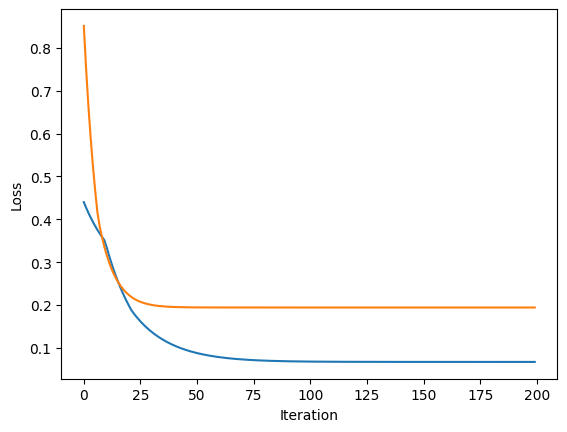

In [69]:
plt.plot(range(len(losses)), losses)
plt.plot(range(len(losses_original)), losses_original)
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.show()

# y_pred = single_neuron.forward(x_true)

In [ ]:
da2 = 2 * (y_pred - y_true) / y_true.size

In [ ]:
drelu = relu_derivative(single_neuron.output_layer._z_output)

In [ ]:
da1 = single_neuron.output_layer._input

In [ ]:
np.dot(da2, drelu.T, da1)

In [ ]:
np.dot(da2.T, da1)

In [ ]:
da = np.dot(np.dot(da2.T, relu_derivative(single_neuron.hidden_layer._z_output)), single_neuron.hidden_layer.weights.T)